In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

utilization_data = {}

base_path = "../../Data/Medicare_Part_B_NSD"

valid_HCPCS = [
    31231, 31233, 31235, 31237, 31238, 31239, 31240,
    31254, 31255, 31256, 31267, 31276, 31287, 31288,
    31290, 31291, 31292, 31293, 31294
]
valid_HCPCS_str = [str(code) for code in valid_HCPCS]

for year in range(2000,2025):
    file_path = f"{base_path}/{year}.csv"
    df = pd.read_csv(file_path)

    df["HCPCS"] = df["HCPCS"].replace("", pd.NA).ffill()
    totals = df[df["MODIFIER"] == "TOTAL"].copy()
    totals["HCPCS"] = pd.to_numeric(totals["HCPCS"], errors="coerce")
    totals = totals.dropna(subset=["HCPCS"])
    totals["HCPCS"] = totals["HCPCS"].astype(int)
    totals["HCPCS"] = totals["HCPCS"].astype(str)
    totals = totals[totals["HCPCS"].isin(valid_HCPCS_str)]

    for col in ["ALLOWED CHARGES", "PAYMENT"]:
        totals[col] = totals[col].str.replace(r"[\$,]", "", regex=True).astype(float)

    totals["Year"] = year
    utilization_data[year] = totals

combined_df = pd.concat(utilization_data.values(), ignore_index=True)

combined_df = combined_df[["HCPCS", "ALLOWED SERVICES", "PAYMENT", "Year"]]

inflation_path = "../../Data/Inflation_Table/inflation_table.csv"
inflation_df = pd.read_csv(inflation_path)

combined_df = combined_df.merge(inflation_df, on="Year", how="left")

combined_df["Medicare Reimbursement (in Millions)"] = pd.to_numeric(combined_df["PAYMENT"], errors="coerce")

combined_df["Medicare Reimbursement (Inflation Adjusted, in Millions)"] = (
    combined_df["Medicare Reimbursement (in Millions)"] * combined_df["Inflation Factor"] / 1.03
)

combined_df["ALLOWED SERVICES"] = (
    combined_df["ALLOWED SERVICES"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [13]:
grouping_path = "../../Supplementary_Tables/ST1/ST1.csv"
grouping_df = pd.read_csv(grouping_path)

combined_df["HCPCS"] = combined_df["HCPCS"].astype(str)
grouping_df["CPT Code"] = grouping_df["CPT Code"].astype(str)

combined_df = combined_df.merge(
    grouping_df[["CPT Code", "Group Name", "Group Number"]],
    left_on="HCPCS",
    right_on="CPT Code",
    how="left"
)

combined_df = combined_df.drop(columns=["CPT Code"])

grouped_df = (
    combined_df
    .groupby(["Year", "Group Name"], as_index=False)
    .sum(numeric_only=True)
)[["Year", "Group Name", "ALLOWED SERVICES", "Medicare Reimbursement (in Millions)", "Medicare Reimbursement (Inflation Adjusted, in Millions)"]]



num_services = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="ALLOWED SERVICES"
).sort_index(axis=1)

reimbursement = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Medicare Reimbursement (in Millions)"
).sort_index(axis=1)

inflation_reimbursement = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Medicare Reimbursement (Inflation Adjusted, in Millions)"
).sort_index(axis=1)

reimbursement_per_service = reimbursement/num_services
inflation_reimbursement_per_service = inflation_reimbursement/num_services

In [14]:
inflation_reimbursement_per_service

Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Group Name,,,,,,,,,,,,,,,,,,,,,
CSF Leak Repair,1637.234754,1560.304447,1440.936303,1425.120290,1486.404652,1439.147826,1332.999596,1265.776778,1199.943190,1169.789117,...,1156.996828,1160.286468,1109.797861,1118.501891,1127.047206,1116.266598,1090.742154,1031.472705,985.073217,969.616812
Concha Bullosa Resection,187.092920,183.988973,170.474308,171.540693,179.767024,173.850758,166.943373,155.600899,157.229847,170.485697,...,241.597757,150.036888,146.506010,145.018001,149.000155,162.857428,167.823103,155.343518,147.482683,152.283377
Dacryocystorhinostomy,871.657417,805.019506,717.671402,733.710337,794.754515,783.710518,750.601819,703.191711,679.005555,687.351161,...,735.493230,714.583463,703.790872,703.361683,703.031848,707.154681,698.999708,653.827555,641.742599,643.513091
Diagnostic Endoscopy,143.526421,152.766990,152.491728,150.846576,225.759422,217.272646,210.356679,200.080277,196.003855,191.124830,...,207.693692,202.093274,192.380225,190.011458,180.665815,168.840665,173.542249,150.956655,137.787108,127.344668
Endoscopy with Biopsy/Debridement,343.946977,353.325308,341.828858,338.120077,450.130807,437.971082,421.649015,391.925928,383.702293,377.016013,...,321.716928,317.265686,306.153891,306.791869,301.578699,294.653786,296.507642,275.443623,257.679823,247.367119
Epistaxis Control,352.189503,362.420945,343.633316,336.698769,413.700353,398.423221,384.313271,355.577740,340.796429,340.500357,...,264.988146,261.312512,250.715342,249.288122,244.173888,235.288815,234.692016,214.779561,200.677991,189.063938
FESS - Ethmoid/Maxillary/Frontal,542.675262,517.182579,474.409588,467.782082,484.742670,468.804667,446.778623,407.159706,388.409743,405.769603,...,497.370465,525.862309,512.845509,462.535974,466.516651,531.748849,542.593921,520.556130,512.054511,522.782004
FESS - Sphenoid,306.633092,287.808700,263.268288,261.798598,273.990747,266.366804,254.246684,233.648664,232.088068,249.483044,...,464.941761,521.306521,516.840446,474.822889,501.111936,546.693137,542.583721,514.822868,495.395371,525.454529
Orbital/Optic Nerve Surgery,1507.354097,1521.577706,1287.996910,1287.187137,1389.158686,1426.519219,1330.671615,1217.711514,1070.679161,1152.329521,...,1098.947954,1108.319586,1054.838469,1053.679985,1056.151838,986.479217,1078.309491,928.449463,903.980630,853.143654


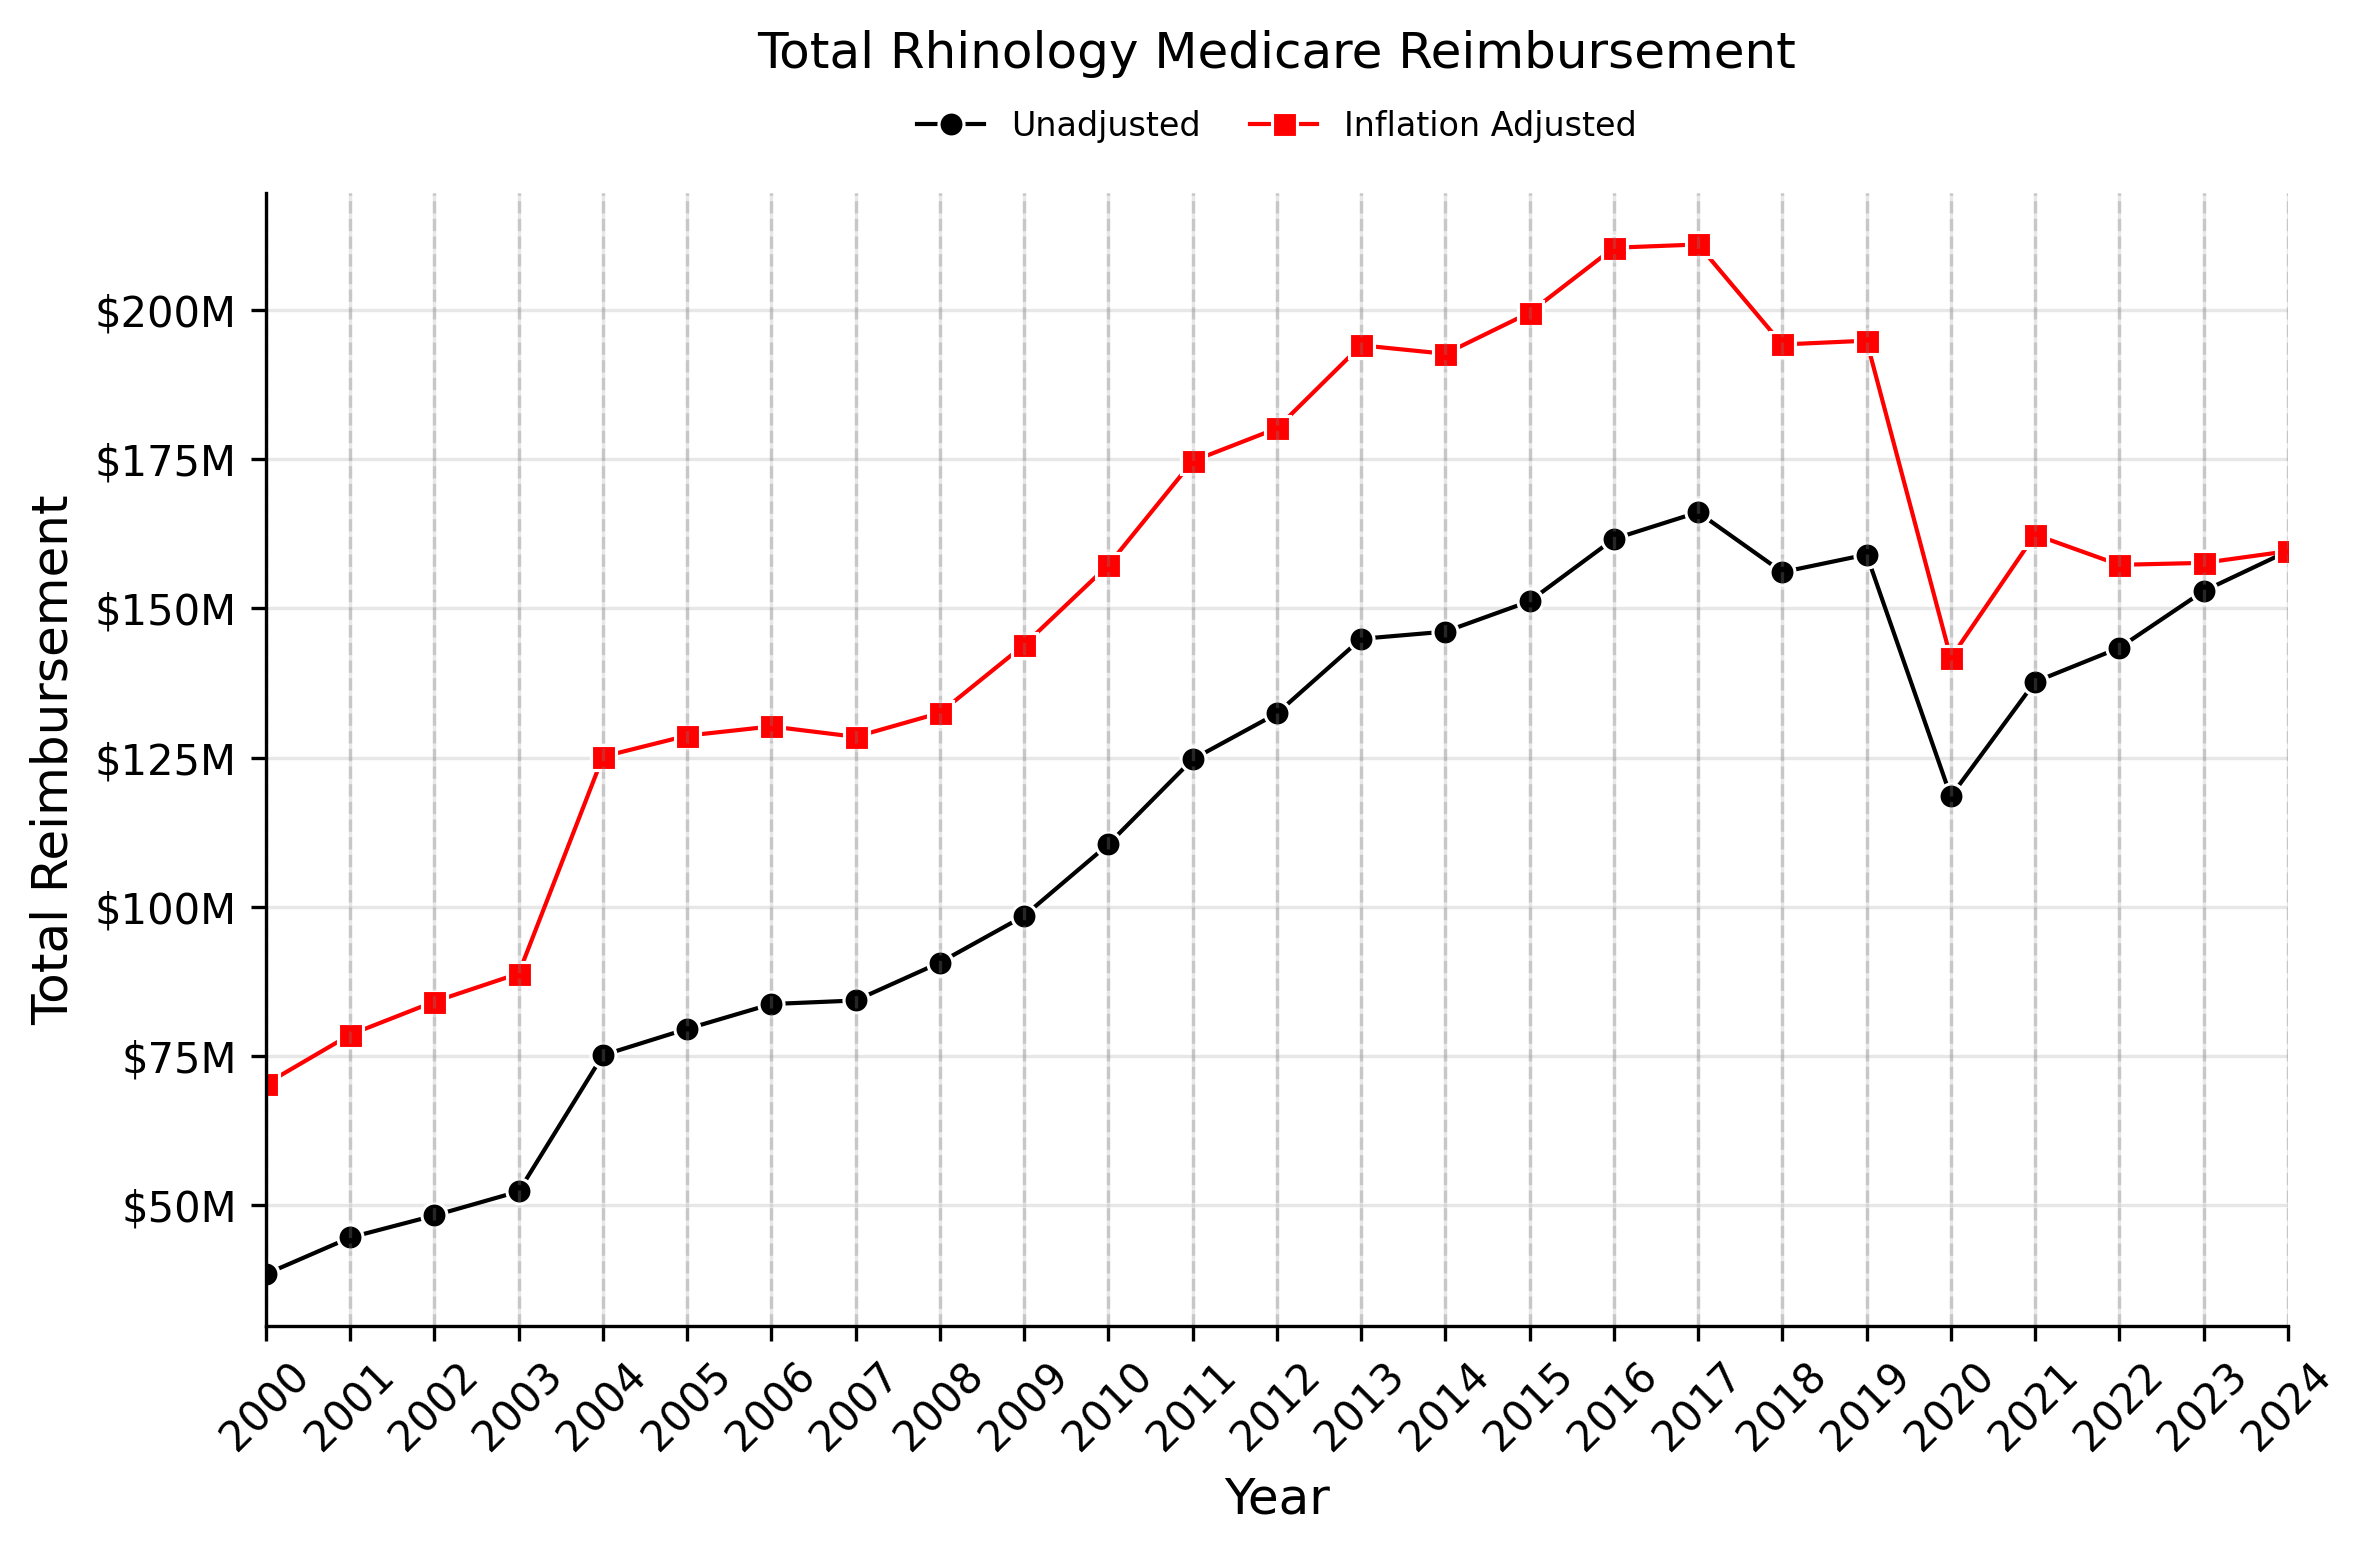

In [32]:
total_unadjusted = reimbursement.sum(axis=0)
total_adjusted = inflation_reimbursement.sum(axis=0)

df_plot = pd.DataFrame({
    'Year': total_unadjusted.index.astype(int),
    'Unadjusted': total_unadjusted.values,
    'Inflation Adjusted': total_adjusted.values
})

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.lineplot(
    data=df_plot, 
    x='Year', 
    y='Unadjusted', 
    marker='o', 
    markersize=6,
    linewidth=1, 
    color='black', 
    label='Unadjusted',
    ax=ax
)

sns.lineplot(
    data=df_plot, 
    x='Year', 
    y='Inflation Adjusted', 
    marker='s', 
    markersize=6,
    linewidth=1, 
    color='red', 
    label='Inflation Adjusted',
    ax=ax
)

plt.title("Total Rhinology Medicare Reimbursement", fontsize=12, pad=30)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Reimbursement", fontsize=12)

ax.set_xlim(2000, 2024)
ax.set_xticks(range(2000, 2025))
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'${x/1e6:g}M'))

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=2,                
    frameon=False,
    fontsize=8,
    handlelength=2.0,
    columnspacing=1.5
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(alpha=0.3)
for year in range(2000, 2026):
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('F4.pdf')
plt.show()

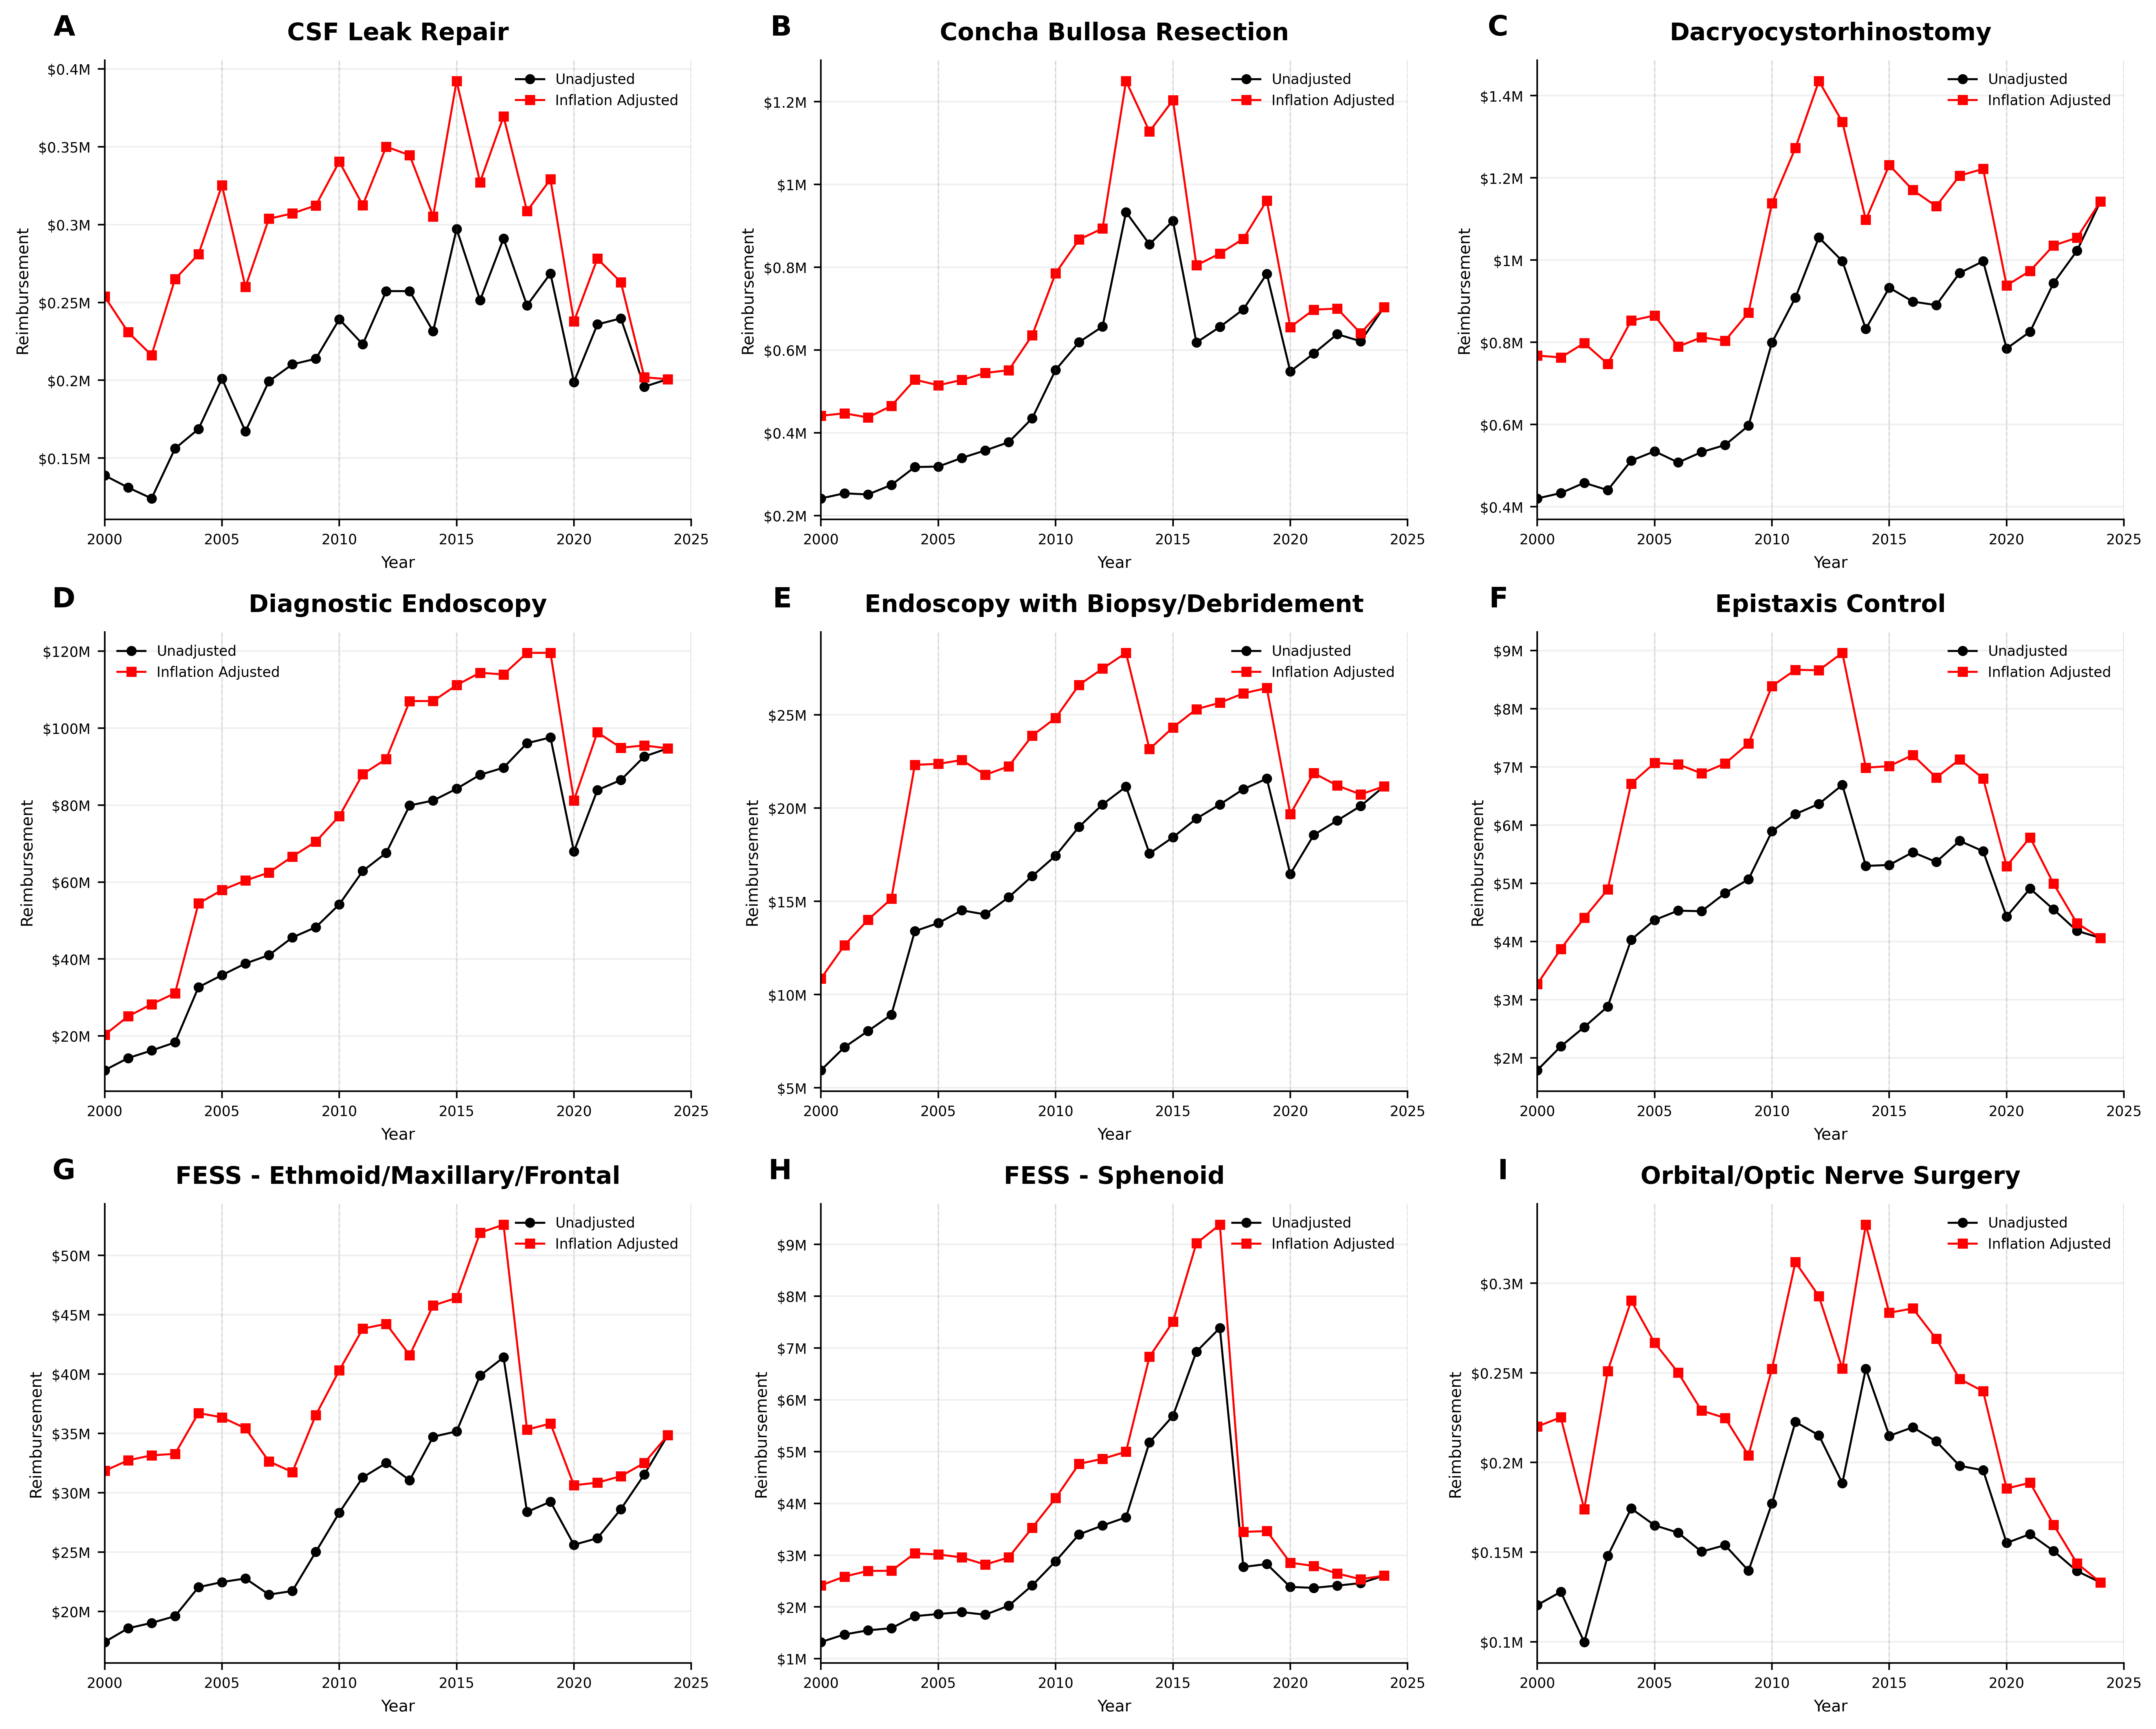

In [31]:
import string
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math
from scipy import stats

alphabet = string.ascii_uppercase
years = np.array([int(c) for c in reimbursement.columns])
groups = reimbursement.index.tolist()
num_groups = len(groups)
grid_size = 9
num_pages = math.ceil(num_groups / grid_size)

for p in range(num_pages):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), dpi=500)
    axes = axes.flatten()
    
    for i in range(grid_size):
        idx = p * grid_size + i
        ax = axes[i]
        
        if idx < num_groups:
            name = groups[idx]
            
            ax.text(-0.05, 1.1, alphabet[i], transform=ax.transAxes, 
                    fontsize=14, fontweight='bold', va='top', ha='right')

            datasets = [
                (reimbursement, 'black', 'o', 'Unadjusted'),
                (inflation_reimbursement, 'red', 's', 'Inflation Adjusted')
            ]
            
            for df_obj, color, marker, label in datasets:
                values = df_obj.loc[name].values
                ax.plot(years, values, marker=marker, markersize=4, 
                        linewidth=1, color=color, label=label)
            
            ax.set_title(name, fontsize=12, pad=10, fontweight='bold')
            ax.set_ylabel('Reimbursement', fontsize=8)
            ax.set_xlabel('Year', fontsize=8)
            
            ax.set_xlim(2000, 2025)
            ax.set_xticks([2000, 2005, 2010, 2015, 2020, 2025])
            ax.tick_params(axis='both', labelsize=7)
            
            ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'${x/1e6:g}M'))
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            ax.grid(alpha=0.2)
            for year in range(2000, 2026, 5):
                ax.axvline(x=year, linestyle="--", color="gray", alpha=0.2, linewidth=0.6)
            
            ax.legend(loc="best", frameon=False, fontsize=7)
        else:
            ax.axis('off')
            
    plt.tight_layout()
    plt.savefig(f'../../Supplementary_Figures/SF2/SF2.pdf')
    plt.show()
    plt.close()